# Finetunear theia con RGB-D

Explicar qué y por qué se hará el fine-tuning de theia

primero se descarga un modelo bebe (theia small)

### Dataset
Aqui explicar porqué se usa ese data y así...

In [1]:
import random
from pathlib import Path

import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as TF


class SUNNYUFolderDataset(Dataset):
    """
    Dataset para la estructura tipo SUNRGBD/NYU:

      root/
        ├── b3dodata/img_0063/
        │     ├── image/img_0063.jpg
        │     ├── depth_bfx/img_0063_abs.png
        │     └── ...
        ├── NYUdata/NYU0010/
              ├── image/NYU0010.jpg
              ├── depth_bfx/NYU0010.png
              └── ...

    Usa:
      - RGB  : image/*.jpg
      - Depth: depth_bfx/*.png  (o depth/*.png si no existe depth_bfx)

    Devuelve:
      - rgb:   [3, 224, 224] float32 en [0,1]
      - depth: [1, 224, 224] float32 en metros
      - index: índice global dentro del split
    """

    def __init__(
        self,
        root_dir,
        resize=(224, 224),
        split="train",
        split_file=None,
        val_ratio=0.15,
        test_ratio=0.15,
        seed=1337,
        augment=True,
    ):
        super().__init__()
        self.root_dir = Path(root_dir)
        if not self.root_dir.exists():
            raise FileNotFoundError(f"No se encontró el directorio raíz: {self.root_dir}")

        if split not in ("train", "val", "test"):
            raise ValueError(f"split debe ser 'train', 'val' o 'test', no '{split}'")

        self.resize = resize
        self.depth_size = resize
        self.split = split
        self.augment = augment and (split == "train")  # solo train se augumenta

        # Transform base para RGB cuando NO hay augment
        self.rgb_transform = T.Compose([
            T.Resize(self.resize, interpolation=T.InterpolationMode.BILINEAR),
            T.ToTensor(),  # [3,H,W] en [0,1]
        ])

        # Color jitter solo para RGB (se aplica dentro de __getitem__)
        self.color_jitter = T.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.05,
        )

        # Descubrimos muestras
        if split_file is not None:
            self.samples = self._load_from_split_file(split_file)
        else:
            all_samples = self._discover_all_samples()
            self.samples = self._make_split(
                all_samples,
                split=split,
                val_ratio=val_ratio,
                test_ratio=test_ratio,
                seed=seed,
            )

    # ------------------------------------------------------------------ #
    # Descubrimiento de escenas
    # ------------------------------------------------------------------ #

    def _discover_all_samples(self):
        samples = []

        image_dirs = list(self.root_dir.rglob("image"))
        for img_dir in image_dirs:
            jpgs = sorted(img_dir.glob("*.jpg"))
            if len(jpgs) == 0:
                continue

            scene_dir = img_dir.parent

            depth_bfx_dir = scene_dir / "depth_bfx"
            depth_dir = scene_dir / "depth"

            depth_path = None
            if depth_bfx_dir.exists():
                pngs = sorted(depth_bfx_dir.glob("*.png"))
                if len(pngs) > 0:
                    depth_path = pngs[0]
            if depth_path is None and depth_dir.exists():
                pngs = sorted(depth_dir.glob("*.png"))
                if len(pngs) > 0:
                    depth_path = pngs[0]

            if depth_path is None:
                continue

            rgb_path = jpgs[0]

            samples.append({
                "scene_dir": scene_dir,
                "rgb_path": rgb_path,
                "depth_path": depth_path,
            })

        if len(samples) == 0:
            raise RuntimeError(
                f"No se encontraron escenas con image/*.jpg y depth[_bfx]/*.png en {self.root_dir}"
            )

        samples = sorted(samples, key=lambda s: str(s["rgb_path"]))
        return samples

    # ------------------------------------------------------------------ #
    # Splits
    # ------------------------------------------------------------------ #

    def _make_split(self, all_samples, split, val_ratio, test_ratio, seed):
        n = len(all_samples)
        if not (0.0 < val_ratio < 1.0 and 0.0 < test_ratio < 1.0 and val_ratio + test_ratio < 1.0):
            raise ValueError("val_ratio y test_ratio deben ser >0 y val+test<1")

        indices = list(range(n))
        rng = random.Random(seed)
        rng.shuffle(indices)

        n_val = int(round(n * val_ratio))
        n_test = int(round(n * test_ratio))
        n_train = n - n_val - n_test

        train_idx = indices[:n_train]
        val_idx = indices[n_train:n_train + n_val]
        test_idx = indices[n_train + n_val:]

        if split == "train":
            chosen = [all_samples[i] for i in train_idx]
        elif split == "val":
            chosen = [all_samples[i] for i in val_idx]
        else:
            chosen = [all_samples[i] for i in test_idx]

        return chosen

    def _load_from_split_file(self, split_file):
        split_path = Path(split_file)
        if not split_path.exists():
            raise FileNotFoundError(f"No se encontró split_file: {split_path}")

        samples = []
        with split_path.open("r") as f:
            for line in f:
                rel = line.strip()
                if not rel:
                    continue
                scene_dir = (self.root_dir / rel).resolve()
                img_dir = scene_dir / "image"
                depth_bfx_dir = scene_dir / "depth_bfx"
                depth_dir = scene_dir / "depth"

                jpgs = sorted(img_dir.glob("*.jpg"))
                if len(jpgs) == 0:
                    continue
                rgb_path = jpgs[0]

                depth_path = None
                if depth_bfx_dir.exists():
                    pngs = sorted(depth_bfx_dir.glob("*.png"))
                    if len(pngs) > 0:
                        depth_path = pngs[0]
                if depth_path is None and depth_dir.exists():
                    pngs = sorted(depth_dir.glob("*.png"))
                    if len(pngs) > 0:
                        depth_path = pngs[0]

                if depth_path is None:
                    continue

                samples.append({
                    "scene_dir": scene_dir,
                    "rgb_path": rgb_path,
                    "depth_path": depth_path,
                })

        if len(samples) == 0:
            raise RuntimeError(
                f"No se encontraron escenas válidas a partir de {split_file}"
            )

        return samples

    # ------------------------------------------------------------------ #
    # Dataset API
    # ------------------------------------------------------------------ #

    def __len__(self):
        return len(self.samples)

    def _augment_pair(self, img_pil, depth_m):
        """
        Aplica las mismas transf geométricas a RGB y depth.
        depth_m: np.array float32 en metros.
        Devuelve img_tensor [3,224,224], depth_tensor [1,224,224].
        """
        # depth_m -> PIL modo 'F'
        depth_pil = Image.fromarray(depth_m)

        # 1) Random horizontal flip
        if random.random() < 0.5:
            img_pil = TF.hflip(img_pil)
            depth_pil = TF.hflip(depth_pil)

        # 2) Random Resized Crop (como RandomResizedCrop)
        scale = (0.8, 1.0)      # rango de escala de área
        ratio = (0.9, 1.1)      # ligera variación de aspecto

        i, j, h, w = T.RandomResizedCrop.get_params(img_pil, scale=scale, ratio=ratio)

        img_pil = TF.resized_crop(
            img_pil, i, j, h, w, self.resize,
            interpolation=T.InterpolationMode.BILINEAR
        )
        depth_pil = TF.resized_crop(
            depth_pil, i, j, h, w, self.resize,
            interpolation=T.InterpolationMode.NEAREST
        )

        # 3) Color jitter solo para RGB
        img_pil = self.color_jitter(img_pil)

        # 4) A tensor
        rgb = TF.to_tensor(img_pil)          # [3,224,224] en [0,1]
        depth_resized = np.array(depth_pil, dtype=np.float32)
        depth = torch.from_numpy(depth_resized).unsqueeze(0)  # [1,224,224]

        return rgb, depth

    def __getitem__(self, idx):
        item = self.samples[idx]
        rgb_path = item["rgb_path"]
        depth_path = item["depth_path"]

        # ---------- RGB ----------
        img_pil = Image.open(rgb_path).convert("RGB")

        # ---------- Depth ----------
        depth_pil_raw = Image.open(depth_path)
        depth_np_raw = np.array(depth_pil_raw, dtype=np.uint16)    # [H,W]
        depth_m = depth_np_raw.astype(np.float32) / 10000.0        # -> metros

        if self.augment:
            rgb, depth = self._augment_pair(img_pil, depth_m)
        else:
            # Sin augment: sólo resize consistente
            rgb = self.rgb_transform(img_pil)  # [3,224,224]

            depth_pil = Image.fromarray(depth_m)
            depth_pil = depth_pil.resize(self.depth_size, resample=Image.NEAREST)
            depth_resized = np.array(depth_pil, dtype=np.float32)
            depth = torch.from_numpy(depth_resized).unsqueeze(0)   # [1,224,224]

        sample = {
            "rgb": rgb,
            "depth": depth,
            "index": idx,
        }
        return sample


## BackBone 2D

Definir el backbone 2d

In [2]:
import torch
import torch.nn as nn
from transformers import AutoModel


class TheiaBackbone2D(nn.Module):
    """
    Wrapper sencillo de Theia:
    - Input: [B, 3, H, W] o [B, H, W, 3] (RGB)
    - Output: [B, D]  (feature global por imagen)
    """
    def __init__(self, model_name: str = "theaiinstitute/theia-base-patch16-224-cdiv"):
        super().__init__()
        self.model = AutoModel.from_pretrained(
            model_name,
            trust_remote_code=True,
        )

        # tratar de exponer embed_dim por si lo necesitas
        try:
            vit = self.model.backbone.model          # ViTModel
            self.embed_dim = vit.config.hidden_size
        except Exception:
            self.embed_dim = self.model.config.hidden_size

    @torch.no_grad()
    def _preprocess_rgb(self, x: torch.Tensor) -> torch.Tensor:
        """
        Acepta:
          - [B,3,H,W] float o uint8
          - [B,H,W,3] float o uint8

        Devuelve:
          - [B,3,H,W] float32 en [0,1]
        """
        # [B,H,W,3] -> [B,3,H,W]
        if x.ndim == 4 and x.shape[1] not in (1, 3):
            # asumimos [B,H,W,3]
            x = x.permute(0, 3, 1, 2).contiguous()

        if x.dtype == torch.uint8:
            x = x.float() / 255.0
        else:
            # si viene como float y parece estar en [0,255], normalizamos
            if x.max() > 1.5:
                x = x / 255.0

        return x.to(torch.float32)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, 3, H, W] o [B, H, W, 3]
        devuelve: [B, D]
        """
        x = self._preprocess_rgb(x)  # [B,3,H,W] float32 en [0,1]

        # ViT "puro" de Theia (dentro del AutoModel)
        vit = self.model.backbone.model  # ViTModel de transformers

        # ⚠️ clave: permitir resoluciones distintas a 224x224
        out = vit(pixel_values=x, interpolate_pos_encoding=True)

        tokens = out.last_hidden_state   # [B, N, D]
        feat_global = tokens.mean(dim=1) # [B, D]
        return feat_global

### Student

Definimos el student RGBD, será un theiabackbone RGBD

In [3]:
import torch
import torch.nn as nn
from transformers import AutoModel


def _find_patch_conv(model: nn.Module):
    candidates = []
    for name, m in model.named_modules():
        if isinstance(m, nn.Conv2d):
            k = m.kernel_size
            s = m.stride
            if (
                m.in_channels == 3 and
                k[0] == k[1] == 16 and
                s[0] == s[1] == 16
            ):
                candidates.append((name, m))

    if len(candidates) == 0:
        raise RuntimeError("No encontré Conv2d de patch embedding (3 canales, k=16, s=16)")
    if len(candidates) > 1:
        print("Advertencia: encontré múltiples candidatos, uso el primero:")
        for name, _ in candidates:
            print(" -", name)
    return candidates[0]  # (name, module)


class ResBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        out = out + x
        out = self.relu(out)
        return out


class TheiaBackboneRGBD(nn.Module):
    def __init__(
        self,

        model_name: str = "theaiinstitute/theia-base-patch16-224-cdiv",
        #model_name: str = "theaiinstitute/theia-small-patch16-224-cdiv",
        use_cls_token: bool = False,
    ):
        super().__init__()
        self.model = AutoModel.from_pretrained(
            model_name,
            trust_remote_code=True,
        )
        self.use_cls_token = use_cls_token

        # ===== STEM RESIDUAL PARA FUSIONAR RGB+DEPTH =====
        stem_channels = 32
        self.stem_in = nn.Conv2d(4, stem_channels, kernel_size=3, padding=1)
        self.stem_block1 = ResBlock(stem_channels)
        self.stem_block2 = ResBlock(stem_channels)
        self.stem_out = nn.Conv2d(stem_channels, 4, kernel_size=3, padding=1)
        self.stem_relu = nn.ReLU(inplace=True)

        # Parchear patch embedding a 4 canales
        self._convert_patch_embed_to_rgbd()

        # Guardar dim de embedding para DepthHead / classifier
        try:
            vit = self.model.backbone.model          # ViTModel
            self.embed_dim = vit.config.hidden_size
        except Exception:
            self.embed_dim = self.model.config.hidden_size

    @torch.no_grad()
    def _preprocess_rgbd(self, x: torch.Tensor) -> torch.Tensor:
        # [B,4,H,W] o [B,H,W,4] -> [B,4,H,W] float32 en ~[0,1]
        if x.ndim == 4 and x.shape[1] not in (3, 4):
            x = x.permute(0, 3, 1, 2).contiguous()

        if x.dtype == torch.uint8:
            x = x.float() / 255.0
        else:
            if x.max() > 1.5:
                x = x / 255.0
        return x.to(torch.float32)

    def _convert_patch_embed_to_rgbd(self):
        name, old_conv = _find_patch_conv(self.model)
        print(f"[RGBD] Patch embedding encontrado en: {name}  (in={old_conv.in_channels}, out={old_conv.out_channels})")

        in_c = 4
        out_c = old_conv.out_channels
        k = old_conv.kernel_size
        s = old_conv.stride
        p = old_conv.padding
        d = old_conv.dilation
        bias = old_conv.bias is not None

        new_conv = nn.Conv2d(
            in_channels=in_c,
            out_channels=out_c,
            kernel_size=k,
            stride=s,
            padding=p,
            dilation=d,
            bias=bias,
        )

        with torch.no_grad():
            # Copiar RGB
            new_conv.weight[:, :3, :, :] = old_conv.weight
            # Canal D = promedio de los 3
            mean_w = old_conv.weight.mean(dim=1, keepdim=True)
            new_conv.weight[:, 3:4, :, :] = mean_w
            if bias:
                new_conv.bias.copy_(old_conv.bias)

        # Reemplazar el conv dentro del modelo
        modules = name.split(".")
        parent = self.model
        for m in modules[:-1]:
            parent = getattr(parent, m)
        setattr(parent, modules[-1], new_conv)

        # Ajustar num_channels en ViT
        try:
            vit = self.model.backbone.model          # ViTModel
            vit.config.num_channels = 4
            if hasattr(vit, "embeddings"):
                pe = vit.embeddings.patch_embeddings  # ViTPatchEmbeddings
                pe.num_channels = 4
        except Exception as e:
            print("[RGBD] Advertencia al ajustar num_channels:", e)

        print("[RGBD] Patch embedding convertido a 4 canales (RGBD).")

    def forward_tokens(self, x: torch.Tensor) -> torch.Tensor:
        # Preprocesar
        x = self._preprocess_rgbd(x)          # [B,4,H,W] float32 en [0,1]

        # STEM residual: 4 -> 32 -> 32 -> 4
        x = self.stem_in(x)                   # [B,32,H,W]
        x = self.stem_relu(x)
        x = self.stem_block1(x)               # [B,32,H,W]
        x = self.stem_block2(x)               # [B,32,H,W]
        x = self.stem_out(x)                  # [B,4,H,W]
        x = self.stem_relu(x)

        vit = self.model.backbone.model       # ViTModel

        # ⚠️ AQUÍ EL CAMBIO: activamos la interpolación de pos. embeddings
        out = vit(pixel_values=x, interpolate_pos_encoding=True)

        tokens = out.last_hidden_state        # [B, N, D]

        # Si hay CLS, lo quitamos para quedarnos sólo con patches
        if tokens.shape[1] == 197 and not self.use_cls_token:
            tokens = tokens[:, 1:, :]

        return tokens

    def forward_global(self, x: torch.Tensor) -> torch.Tensor:
        tokens = self.forward_tokens(x)       # [B,N,D]
        return tokens.mean(dim=1)             # [B,D]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.forward_global(x)

### Head de profundidad

se define un mapa [B,D,14,14]

In [4]:
class ResBlock2d(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(ch)
        self.bn2   = nn.BatchNorm2d(ch)
        self.act   = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.act(out + identity)
        return out


class DepthHeadBig(nn.Module):
    """
    Decoder de profundidad más pesado:
      - tokens [B,N,D] → mapa [B,1,H,W]
      - varios convs + upsampling progresivo
    """
    def __init__(self, embed_dim: int, out_size=(224, 224)):
        super().__init__()
        self.embed_dim = embed_dim
        self.out_size = out_size

        self.proj = nn.Conv2d(embed_dim, 256, kernel_size=1)

        self.block1 = ResBlock2d(256)
        self.block2 = ResBlock2d(256)

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        self.block3 = ResBlock2d(128)

        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.block4 = ResBlock2d(64)

        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        self.conv_out = nn.Conv2d(32, 1, kernel_size=3, padding=1)

    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        """
        tokens: [B,N,D]
          - N puede ser S*S (solo patches)
          - o 1 + S*S (CLS + patches)
        """
        B, N, D = tokens.shape

        # Intentar asumir que ya viene solo patches
        S = int(N ** 0.5)

        if S * S != N:
            # Probablemente viene [CLS] + patches → N-1 debe ser cuadrado
            N_wo_cls = N - 1
            S_wo = int(N_wo_cls ** 0.5)
            if S_wo * S_wo == N_wo_cls:
                # quitamos el CLS
                tokens = tokens[:, 1:, :]   # [B, N-1, D]
                N = N_wo_cls
                S = S_wo
            else:
                raise AssertionError(
                    f"N={N} no es cuadrado ni N-1={N_wo_cls} tampoco; no sé mapear tokens a grid."
                )

        # [B,N,D] -> [B,D,S,S]
        x = tokens.transpose(1, 2).reshape(B, D, S, S)

        x = self.proj(x)        # [B,256,S,S]
        x = self.block1(x)
        x = self.block2(x)

        x = self.up1(x)         # [B,128,...]
        x = self.block3(x)

        x = self.up2(x)         # [B, 64,...]
        x = self.block4(x)

        x = self.up3(x)         # [B, 32,...]

        x_up = F.interpolate(
            x,
            size=self.out_size,
            mode="bilinear",
            align_corners=False,
        )
        depth = self.conv_out(x_up)      # [B,1,H,W]
        depth = torch.sigmoid(depth)
        return depth


## combinar student y backbone

se combinan los backbone

In [5]:
import torch
import torch.nn as nn


class TheiaRGBDStudent(nn.Module):
    """
    Student RGBD con:
      - backbone Theia RGBD (ViT base)
      - 1–2 capas de TransformerEncoder para refinar tokens
      - DepthHead gordito para predecir mapa de profundidad

    img_size: tamaño de entrada (y salida de depth), ej. 320.
    """
    def __init__(
        self,
        model_name: str = "theaiinstitute/theia-base-patch16-224-cdiv",
        num_refine_layers: int = 2,
        embed_dim: int = 768,   # theia-base → 768; si cambias modelo, ajusta
        img_size: int = 320,
    ):
        super().__init__()

        self.img_size = img_size

        # Backbone RGBD (parcheado a 4 canales como ya lo tenías)
        self.backbone = TheiaBackboneRGBD(
            model_name=model_name,
            use_cls_token=False,
        )

        # Bloques Transformer extra para refinar tokens [B,N,D]
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=8,                 # 8 cabezas para D=768
            dim_feedforward=embed_dim * 4,
            batch_first=True,        # para usar [B,N,D]
        )
        self.token_refiner = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_refine_layers,
        )

        # DepthHead gordito, ahora con salida img_size x img_size (ej. 320x320)
        self.depth_head = DepthHeadBig(
            embed_dim,
            out_size=(img_size, img_size),
        )

    def forward_tokens(self, x_rgbd: torch.Tensor) -> torch.Tensor:
        """
        x_rgbd: [B,4,img_size,img_size]
        return: tokens_refined [B,N,D]
        """
        tokens = self.backbone.forward_tokens(x_rgbd)   # [B,N,D]
        tokens_refined = self.token_refiner(tokens)     # [B,N,D]
        return tokens_refined

    def forward_global(self, x_rgbd: torch.Tensor) -> torch.Tensor:
        """
        Regresa el feature global (para distillation).
        """
        tokens_refined = self.forward_tokens(x_rgbd)    # [B,N,D]
        feat_global = tokens_refined.mean(dim=1)        # [B,D]
        return feat_global

    def forward(self, x_rgbd: torch.Tensor):
        """
        Salida estándar:
          feat_global: [B,D]              → para distillation
          depth_pred:  [B,1,img_size,img_size]  (ej. [B,1,320,320])
        """
        tokens_refined = self.forward_tokens(x_rgbd)    # [B,N,D]
        feat_global = tokens_refined.mean(dim=1)        # [B,D]
        depth_pred = self.depth_head(tokens_refined)    # [B,1,320,320]
        return feat_global, depth_pred


In [6]:
import torch
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader

# Pesos de las pérdidas
W_L1       = 1.0   # pérdida L1 de profundidad
W_GRAD     = 0.5   # pérdida de gradiente
W_SSIM     = 0.08   # pérdida SSIM
W_DISTILL  = 0.15   # distillation (cosine)


def gradient_loss(pred, target):
    """
    Penaliza diferencias de gradiente (bordes) entre pred y target.
    pred, target: [B,1,H,W] en [0,1]
    """
    pred_dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    pred_dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]

    tgt_dx = target[:, :, :, 1:] - target[:, :, :, :-1]
    tgt_dy = target[:, :, 1:, :] - target[:, :, :-1, :]

    Lx = (pred_dx - tgt_dx).abs().mean()
    Ly = (pred_dy - tgt_dy).abs().mean()
    return Lx + Ly


def ssim_loss(pred, target):
    """
    SSIM loss en [0,1], versión sencilla.
    pred, target: [B,1,H,W] en [0,1]
    """
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    mu_pred   = F.avg_pool2d(pred, 3, 1, 0)
    mu_target = F.avg_pool2d(target, 3, 1, 0)

    sigma_pred   = F.avg_pool2d(pred * pred, 3, 1, 0) - mu_pred ** 2
    sigma_target = F.avg_pool2d(target * target, 3, 1, 0) - mu_target ** 2
    sigma_xy     = F.avg_pool2d(pred * target, 3, 1, 0) - mu_pred * mu_target

    ssim_n = (2 * mu_pred * mu_target + C1) * (2 * sigma_xy + C2)
    ssim_d = (mu_pred ** 2 + mu_target ** 2 + C1) * (sigma_pred + sigma_target + C2)

    ssim_map = ssim_n / (ssim_d + 1e-7)
    # convertimos SSIM a "pérdida"
    loss = torch.clamp((1.0 - ssim_map) / 2.0, 0.0, 1.0)
    return loss.mean()


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

root = "SUNRGBD/kv1"  

train_ds = SUNNYUFolderDataset(
    root_dir=root,
    resize=(320, 320),
    split="train",
    augment=True,
)

val_ds = SUNNYUFolderDataset(
    root_dir=root,
    resize=(320, 320),
    split="val",
    augment=False,
)

test_ds = SUNNYUFolderDataset(
    root_dir=root,
    resize=(320, 320),
    split="test",
    augment=False,
)

train_loader = DataLoader(
    train_ds,
    batch_size=11,       # yo bajaría a 4–8 con la 3060
    shuffle=True,
    num_workers=16,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=11,
    shuffle=False,
    num_workers=16,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=11,
    shuffle=False,
    num_workers=16,
    pin_memory=True,
)


# ---------- Teacher 2D (congelado) ----------
teacher = TheiaBackbone2D().to(device).eval()
for p in teacher.parameters():
    p.requires_grad = False

# ---------- Student RGBD ----------
student = TheiaRGBDStudent().to(device).train()

# ---------- Optimizador + AMP ----------
opt = torch.optim.AdamW(student.parameters(), lr=1e-4, weight_decay=1e-4)
scaler = GradScaler()

MAX_DEPTH_METERS = 10.0      # clip para normalizar depth
LAMBDA_DEPTH = 1.0           # peso de la pérdida de profundidad


def training_step(batch):
    rgb   = batch["rgb"].to(device)    # [B,3,224,224], float [0,1]
    depth = batch["depth"].to(device)  # [B,1,224,224], float (m)

    # --------- Depth GT: normalizada [0,1] ---------
    depth_clipped = depth.clamp(0.0, MAX_DEPTH_METERS)   # en metros
    depth_norm    = depth_clipped / MAX_DEPTH_METERS     # [0,1]

    # --------- Armar RGBD ---------
    rgbd = torch.cat([rgb, depth_norm], dim=1)           # [B,4,224,224]

    # --------- Teacher (2D, congelado) ---------
    with torch.no_grad():
        feat_teacher = teacher(rgb)                      # [B,D]

    # --------- Student RGBD con AMP ---------
    with torch.cuda.amp.autocast():
        feat_student, depth_pred = student(rgbd)         # [B,D], [B,1,224,224]

        # Por seguridad (por si algún día quitas el sigmoid del head)
        depth_pred = depth_pred.clamp(0.0, 1.0)

        # ----- L1 lineal [0,1] -----
        L_L1_lin = F.l1_loss(depth_pred, depth_norm)

        # ----- L1 log (en metros) -----
        eps      = 1e-3
        pred_m   = depth_pred * MAX_DEPTH_METERS         # [B,1,H,W] en m
        pred_log = torch.log(pred_m      + eps)
        gt_log   = torch.log(depth_clipped + eps)
        L_L1_log = F.l1_loss(pred_log, gt_log)

        # Combinar ambas (puedes ajustar los pesos si quieres)
        L_L1 = 0.5 * L_L1_lin + 0.5 * L_L1_log

        # ----- Gradiente + SSIM -----
        L_grad = gradient_loss(depth_pred, depth_norm)
        L_ssim = ssim_loss(depth_pred, depth_norm)

        L_depth = (
            W_L1   * L_L1   +
            W_GRAD * L_grad +
            W_SSIM * L_ssim
        )

        # ----- Distillation: cosine similarity -----
        cos_sim   = F.cosine_similarity(feat_student, feat_teacher, dim=1).mean()
        L_distill = 1.0 - cos_sim

        # ----- Pérdida total -----
        L_total = L_depth + W_DISTILL * L_distill

        # ====== MÉTRICAS DE “EXACTITUD” ======

        # RMSE en [0,1] (sobre depth_norm)
        rmse = torch.sqrt(F.mse_loss(depth_pred, depth_norm))

        # AbsRel en metros (solo donde GT > 0)
        mask = depth_clipped > 0.0
        if mask.any():
            abs_rel = (torch.abs(pred_m - depth_clipped) /
                       (depth_clipped + eps))
            abs_rel = abs_rel[mask].mean()
        else:
            abs_rel = torch.tensor(0.0, device=device)

        # delta1: % de píxeles donde pred y GT difieren poco
        # max(pred/gt, gt/pred) < 1.25 (clásico en depth)
        if mask.any():
            ratio = torch.maximum(
                pred_m[mask] / (depth_clipped[mask] + eps),
                depth_clipped[mask] / (pred_m[mask] + eps)
            )
            delta1 = (ratio < 1.25).float().mean()
        else:
            delta1 = torch.tensor(0.0, device=device)

    # ------ Diccionario de métricas (DETACHED, para log/curvas) ------
    metrics = {
        "L_total":   L_total.detach().cpu().item(),
        "L_depth":   L_depth.detach().cpu().item(),
        "L_L1_lin":  L_L1_lin.detach().cpu().item(),
        "L_L1_log":  L_L1_log.detach().cpu().item(),
        "L_grad":    L_grad.detach().cpu().item(),
        "L_ssim":    L_ssim.detach().cpu().item(),
        "L_distill": L_distill.detach().cpu().item(),
        "rmse":      rmse.detach().cpu().item(),
        "abs_rel":   abs_rel.detach().cpu().item(),
        "delta1":    delta1.detach().cpu().item(),
    }

    # devolvemos loss para backprop + métricas para logging
    return L_total, metrics




Device: cuda


Some weights of ViTModel were not initialized from the model checkpoint at facebook/deit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Some weights of ViTModel were not initialized from the model checkpoint at facebook/deit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast ima

[RGBD] Patch embedding encontrado en: backbone.model.embeddings.patch_embeddings.projection  (in=3, out=768)
[RGBD] Patch embedding convertido a 4 canales (RGBD).


/tmp/ipykernel_65093/2608958769.py:114: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [7]:
from torch.cuda.amp import GradScaler
import math

NUM_EPOCHS       = 100
LR               = 3e-5
MAX_DEPTH_METERS = 10.0

student = student.to(device)
teacher = teacher.to(device).eval()
for p in teacher.parameters():
    p.requires_grad = False

opt    = torch.optim.AdamW(student.parameters(), lr=LR, weight_decay=1e-4)
scaler = GradScaler()

best_epoch_loss = float("inf")

# history guarda PROMEDIOS por época (TRAIN)
history = {
    "L_total":   [],
    "L_depth":   [],
    "L_L1_lin":  [],
    "L_L1_log":  [],
    "L_grad":    [],
    "L_ssim":    [],
    "L_distill": [],
    "rmse":      [],
    "abs_rel":   [],
    "delta1":    [],
}

# history para VALIDACIÓN (mismas llaves)
val_history = {k: [] for k in history.keys()}

for epoch in range(NUM_EPOCHS):
    # ===================== TRAIN =====================
    student.train()

    running = {
        "L_total":   0.0,
        "L_depth":   0.0,
        "L_L1_lin":  0.0,
        "L_L1_log":  0.0,
        "L_grad":    0.0,
        "L_ssim":    0.0,
        "L_distill": 0.0,
        "rmse":      0.0,
        "abs_rel":   0.0,
        "delta1":    0.0,
    }

    for step, batch in enumerate(train_loader):
        opt.zero_grad(set_to_none=True)

        # -------- forward + loss + métricas --------
        L_total, metrics = training_step(batch)

        # -------- backward con AMP + clip --------
        scaler.scale(L_total).backward()

        # Unscale antes de hacer clip (forma recomendada)
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)

        scaler.step(opt)
        scaler.update()

        # -------- acumular métricas para promedio de la época --------
        for k in running.keys():
            running[k] += metrics[k]

        # -------- print cada cierto número de steps --------
        if step % 50 == 0:
            print(
                f"[ep {epoch:02d} step {step:04d}] "
                f"L_tot={metrics['L_total']:.4f}  "
                f"L_depth={metrics['L_depth']:.4f}  "
                f"L1_lin={metrics['L_L1_lin']:.4f}  "
                f"L1_log={metrics['L_L1_log']:.4f}  "
                f"Lgrad={metrics['L_grad']:.4f}  "
                f"Lssim={metrics['L_ssim']:.4f}  "
                f"Ldist={metrics['L_distill']:.4f}  "
                f"rmse={metrics['rmse']:.4f}  "
                f"delta1={metrics['delta1']:.4f}"
            )

    # ---------------- Promedios de la época (TRAIN) ----------------
    n_batches = len(train_loader)
    epoch_train = {k: v / n_batches for k, v in running.items()}

    print(
        f"===> [EPOCH {epoch:02d}][TRAIN] "
        f"L_tot={epoch_train['L_total']:.4f}  "
        f"L_depth={epoch_train['L_depth']:.4f}  "
        f"L1_lin={epoch_train['L_L1_lin']:.4f}  "
        f"L1_log={epoch_train['L_L1_log']:.4f}  "
        f"Lgrad={epoch_train['L_grad']:.4f}  "
        f"Lssim={epoch_train['L_ssim']:.4f}  "
        f"Ldist={epoch_train['L_distill']:.4f}  "
        f"rmse={epoch_train['rmse']:.4f}  "
        f"abs_rel={epoch_train['abs_rel']:.4f}  "
        f"delta1={epoch_train['delta1']:.4f}"
    )

    # Guardar en history (TRAIN) para graficar luego
    for k in history.keys():
        history[k].append(epoch_train[k])

    # ===================== VALIDACIÓN =====================
    student.eval()
    running_val = {
        "L_total":   0.0,
        "L_depth":   0.0,
        "L_L1_lin":  0.0,
        "L_L1_log":  0.0,
        "L_grad":    0.0,
        "L_ssim":    0.0,
        "L_distill": 0.0,
        "rmse":      0.0,
        "abs_rel":   0.0,
        "delta1":    0.0,
    }

    with torch.no_grad():
        for batch in val_loader:
            L_val, metrics_val = training_step(batch)
            for k in running_val.keys():
                running_val[k] += metrics_val[k]

    n_val_batches = len(val_loader)
    epoch_val = {k: v / n_val_batches for k, v in running_val.items()}

    print(
        f"===> [EPOCH {epoch:02d}][VAL]   "
        f"L_tot={epoch_val['L_total']:.4f}  "
        f"L_depth={epoch_val['L_depth']:.4f}  "
        f"L1_lin={epoch_val['L_L1_lin']:.4f}  "
        f"L1_log={epoch_val['L_L1_log']:.4f}  "
        f"Lgrad={epoch_val['L_grad']:.4f}  "
        f"Lssim={epoch_val['L_ssim']:.4f}  "
        f"Ldist={epoch_val['L_distill']:.4f}  "
        f"rmse={epoch_val['rmse']:.4f}  "
        f"abs_rel={epoch_val['abs_rel']:.4f}  "
        f"delta1={epoch_val['delta1']:.4f}"
    )

    # Guardar en val_history para graficar luego
    for k in val_history.keys():
        val_history[k].append(epoch_val[k])

    # Guardar mejor modelo según VALIDACIÓN
    if epoch_val["L_total"] < best_epoch_loss:
        best_epoch_loss = epoch_val["L_total"]
        torch.save(student.state_dict(), "student_rgbd_best.pth")
        print(f"    ✔ Nuevo mejor modelo guardado (VAL L_tot={best_epoch_loss:.4f})")


/tmp/ipykernel_65093/4266128542.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_65093/2608958769.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[ep 00 step 0000] L_tot=0.9818  L_depth=0.8875  L1_lin=0.4054  L1_log=1.2502  Lgrad=0.0603  Lssim=0.3694  Ldist=0.6287  rmse=0.4197  delta1=0.0236
[ep 00 step 0050] L_tot=0.6478  L_depth=0.6208  L1_lin=0.2707  L1_log=0.9251  Lgrad=0.0162  Lssim=0.1846  Ldist=0.1804  rmse=0.3160  delta1=0.1019
[ep 00 step 0100] L_tot=0.5432  L_depth=0.5263  L1_lin=0.2131  L1_log=0.8049  Lgrad=0.0104  Lssim=0.1509  Ldist=0.1126  rmse=0.2629  delta1=0.1388
===> [EPOCH 00][TRAIN] L_tot=0.6697  L_depth=0.6435  L1_lin=0.2720  L1_log=0.9688  Lgrad=0.0152  Lssim=0.1937  Ldist=0.1745  rmse=0.3015  abs_rel=2.0274  delta1=0.0711
===> [EPOCH 00][VAL]   L_tot=0.5143  L_depth=0.4959  L1_lin=0.1877  L1_log=0.7732  Lgrad=0.0084  Lssim=0.1408  Ldist=0.1223  rmse=0.2198  abs_rel=1.4511  delta1=0.1224
    ✔ Nuevo mejor modelo guardado (VAL L_tot=0.5143)
[ep 01 step 0000] L_tot=0.4647  L_depth=0.4455  L1_lin=0.1814  L1_log=0.6816  Lgrad=0.0088  Lssim=0.1201  Ldist=0.1281  rmse=0.2054  delta1=0.0907
[ep 01 step 0050] L_tot

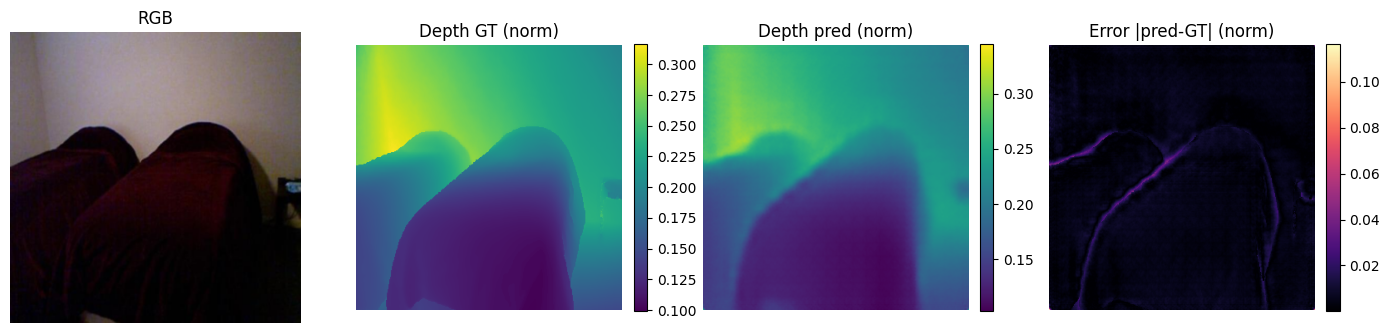

Ejemplo 0: depth GT en metros ~ [0.99, 3.17]


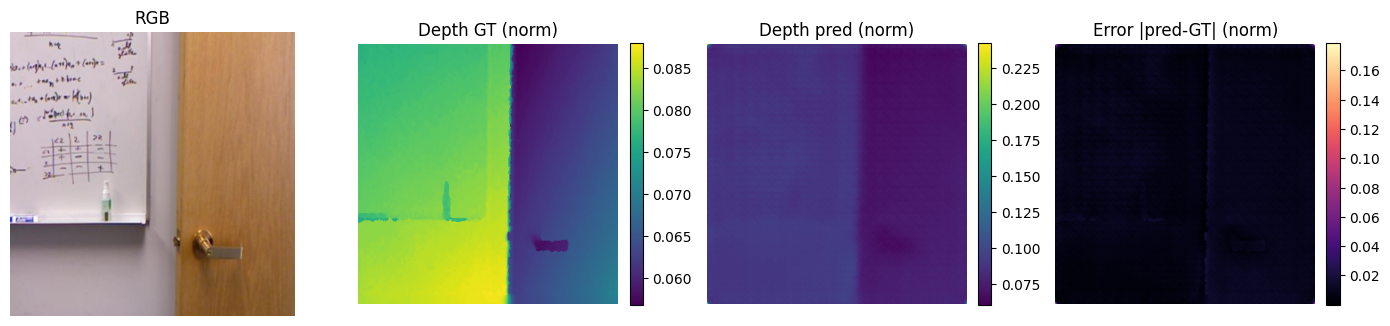

Ejemplo 1: depth GT en metros ~ [0.57, 0.88]


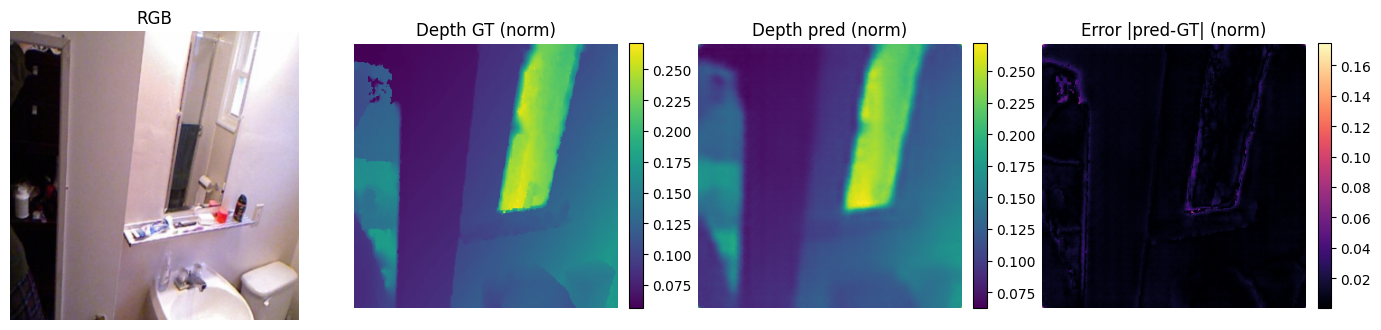

Ejemplo 2: depth GT en metros ~ [0.56, 2.71]


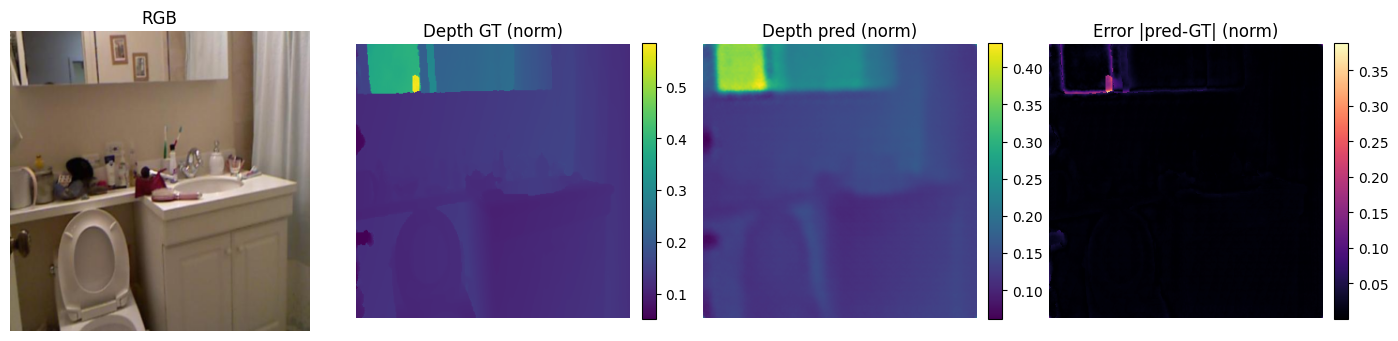

Ejemplo 3: depth GT en metros ~ [0.51, 5.83]


In [8]:
import matplotlib.pyplot as plt
import torch
import numpy as np

student.eval()

# toma un batch del *val_loader* (puedes cambiar a test_loader si quieres)
batch = next(iter(val_loader))
rgb   = batch["rgb"].to(device)       # [B,3,224,224]
depth = batch["depth"].to(device)     # [B,1,224,224] en metros

# ---------- Normalizar depth como en el training ----------
depth_clipped = depth.clamp(0.0, MAX_DEPTH_METERS)      # en metros
depth_norm    = depth_clipped / MAX_DEPTH_METERS        # [0,1]
rgbd          = torch.cat([rgb, depth_norm], dim=1)     # [B,4,224,224]

with torch.no_grad():
    feat_student, depth_pred = student(rgbd)            # [B,D], [B,1,224,224]

    # Por seguridad, igual que en training_step
    depth_pred = depth_pred.clamp(0.0, 1.0)

# ---------- Pasamos a CPU para graficar ----------
rgb_np      = rgb.cpu().numpy()               # [B,3,224,224], [0,1]
depth_norm_np = depth_norm.cpu().numpy()      # [B,1,224,224], [0,1]
pred_np     = depth_pred.cpu().numpy()        # [B,1,224,224], [0,1]

# También en metros (por si quieres ver escala real)
depth_m_np  = depth_clipped.cpu().numpy()     # [B,1,224,224], m
pred_m_np   = pred_np * MAX_DEPTH_METERS      # [B,1,224,224], m

# Error absoluto en normalizado
err_np = np.abs(pred_np - depth_norm_np)      # [B,1,224,224]

# muestra primeros N ejemplos
N = min(4, rgb_np.shape[0])

for i in range(N):
    fig, axs = plt.subplots(1, 4, figsize=(14, 4))

    # RGB
    axs[0].imshow(np.transpose(rgb_np[i], (1, 2, 0)))
    axs[0].set_title("RGB")
    axs[0].axis("off")

    # Depth GT (norm)
    im1 = axs[1].imshow(depth_norm_np[i, 0], cmap="viridis")
    axs[1].set_title("Depth GT (norm)")
    axs[1].axis("off")
    fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

    # Depth pred (norm)
    im2 = axs[2].imshow(pred_np[i, 0], cmap="viridis")
    axs[2].set_title("Depth pred (norm)")
    axs[2].axis("off")
    fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

    # Error |pred-GT|
    im3 = axs[3].imshow(err_np[i, 0], cmap="magma")
    axs[3].set_title("Error |pred-GT| (norm)")
    axs[3].axis("off")
    fig.colorbar(im3, ax=axs[3], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    # Si algún día quieres ver también en metros, puedes imprimir algo así:
    d_min = depth_m_np[i, 0].min()
    d_max = depth_m_np[i, 0].max()
    print(f"Ejemplo {i}: depth GT en metros ~ [{d_min:.2f}, {d_max:.2f}]")


In [9]:
ckpt_path = "theia_rgbd_student_nyu_100_ep_newData.pt"
torch.save({
    "student_state_dict": student.state_dict(),
    "config": {
        "model_name": "theaiinstitute/theia-small-patch16-224-cdiv",
        "max_depth_m": MAX_DEPTH_METERS,
        "lambda_depth": LAMBDA_DEPTH,
    }
}, ckpt_path)

print("Checkpoint guardado en:", ckpt_path)


Checkpoint guardado en: theia_rgbd_student_nyu_100_ep_newData.pt


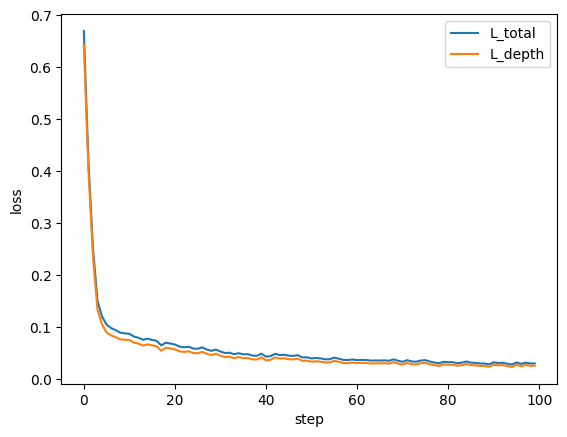

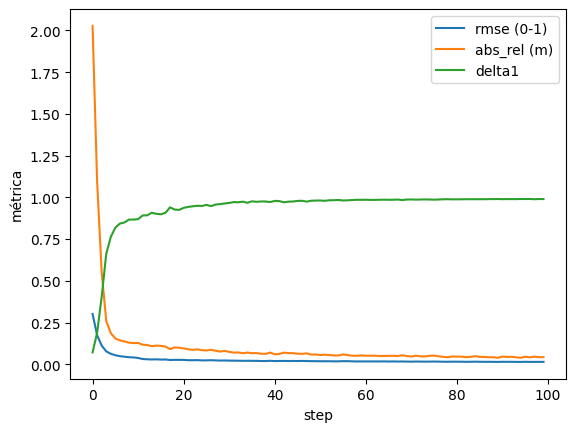

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history["L_total"])
plt.plot(history["L_depth"])
plt.legend(["L_total", "L_depth"])
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

plt.figure()
plt.plot(history["rmse"], label="rmse (0-1)")
plt.plot(history["abs_rel"], label="abs_rel (m)")
plt.plot(history["delta1"], label="delta1")
plt.legend()
plt.xlabel("step")
plt.ylabel("métrica")
plt.show()
